In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import quantile_test
from astropy.stats import binom_conf_interval

martini = Path("/scratch/s4636708/aida/derived/martini")
models = ["CDM", "SIDM1", "vSIDM"]
redshifts = [0.5, 1, 2, 3, 4, 5]

# a galaxy has a central hole if its first fitted ring starts more than this far from the centre (arcsec)
min_hole = 1.0

# 1sigma confidence level
confidence = 0.683

In [2]:
first = {} # (model, z) -> list of (radius in kpc, start in arcsec)
logm = {} # (model, z) -> log10 stellar mass of the same galaxies, in the same order
for model in models:
    for z in redshifts:
        first[(model, z)] = []
        logm[(model, z)] = []
        for info_file in sorted((martini / f"z{z:g}" / model).glob("gal_*/info.json")):
            info = json.load(open(info_file))
            rings_file = info_file.parent / "bbarolo" / "rings_final2.txt"
            if info.get("IsDisc") != 1 or not rings_file.exists():
                continue # not in the sample, or no final fit
            rings = np.loadtxt(rings_file, ndmin=2)
            radius_kpc, radius_arcsec = rings[0, 0], rings[0, 1]
            start_arcsec = radius_arcsec - info["ring_width_arcsec"] / 2
            first[(model, z)].append((radius_kpc, start_arcsec))
            logm[(model, z)].append(np.log10(info["Mstar"]))

CDM    z = 0.5    73 of  458 have central hole
CDM    z = 1      44 of  423 have central hole
CDM    z = 2       9 of  259 have central hole
CDM    z = 3       4 of  122 have central hole
CDM    z = 4       0 of   23 have central hole
CDM    z = 5       0 of    1 have central hole
SIDM1  z = 0.5    62 of  502 have central hole
SIDM1  z = 1      37 of  477 have central hole
SIDM1  z = 2       8 of  312 have central hole
SIDM1  z = 3       1 of  139 have central hole
SIDM1  z = 4       0 of   33 have central hole
SIDM1  z = 5       0 of    4 have central hole
vSIDM  z = 0.5    61 of  458 have central hole
vSIDM  z = 1      41 of  437 have central hole
vSIDM  z = 2       8 of  282 have central hole
vSIDM  z = 3       1 of  115 have central hole
vSIDM  z = 4       0 of   24 have central hole
vSIDM  z = 5       0 of    3 have central hole


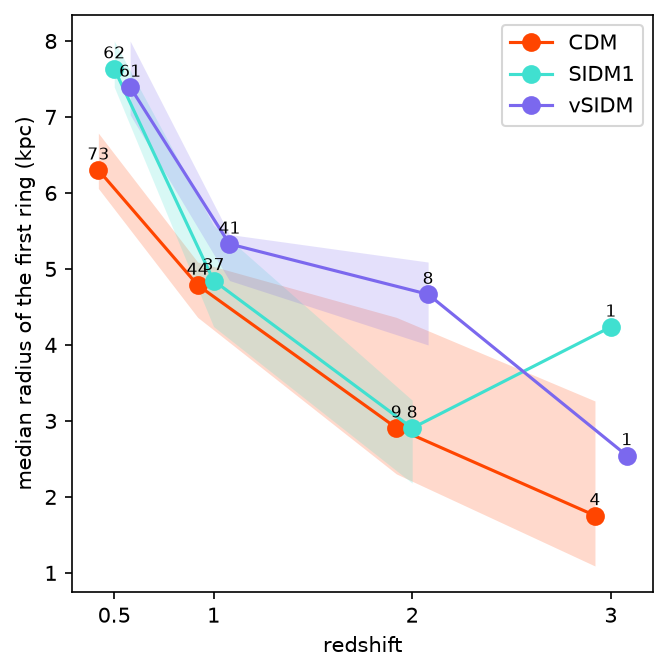

In [19]:
offset = {"CDM": -0.08, "SIDM1": 0.0, "vSIDM": 0.08} # small shifts in z, so the points don't overlap
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
shown = set() # redshifts where some model has a value, for the ticks
for model in models:
    medians, lows, highs = [], [], []
    for z in redshifts:
        r = np.array([radius for radius, start in first[(model, z)] if start > min_hole])
        if len(r):
            m = np.median(r)
            ci = quantile_test(r, p=0.5).confidence_interval(confidence_level=confidence)
            lo, hi = ci.low, ci.high
        else:
            m = lo = hi = np.nan
        medians.append(m)
        lows.append(lo)
        highs.append(hi)
        print(f"{model:6s} z = {z:<4g} {len(r):4d} of {len(first[(model, z)]):4d} have central hole")
        # ax.annotate(f"{len(r)}/{len(first[(model, z)]):.0f}%", (z + offset[model], m), textcoords="offset points", xytext=(0, 5),
        #             ha="center", fontsize=8, color={"CDM": "orangered", "SIDM1": "turquoise", "vSIDM": "mediumslateblue"}[model])
        ax.annotate(f"{len(r):d}", (z + offset[model], m), textcoords="offset points", xytext=(0, 5),
                    ha="center", fontsize=8)
    color = {"CDM": "orangered", "SIDM1": "turquoise", "vSIDM": "mediumslateblue"}[model]
    ax.plot(np.array(redshifts) + offset[model], medians, "o-", markersize=8, label=model, color=color)
    ax.fill_between(np.array(redshifts) + offset[model], lows, highs, color=color, alpha=0.2, lw=0) # range of the median
    shown.update(z for z, v in zip(redshifts, medians) if np.isfinite(v) and v != 0)
ax.set_xlabel("redshift")
ax.set_xticks(sorted(shown), [f"{z:g}" for z in sorted(shown)]) # only the redshifts with data
ax.set_ylabel("median radius of the first ring (kpc)")
ax.legend()
plt.show()

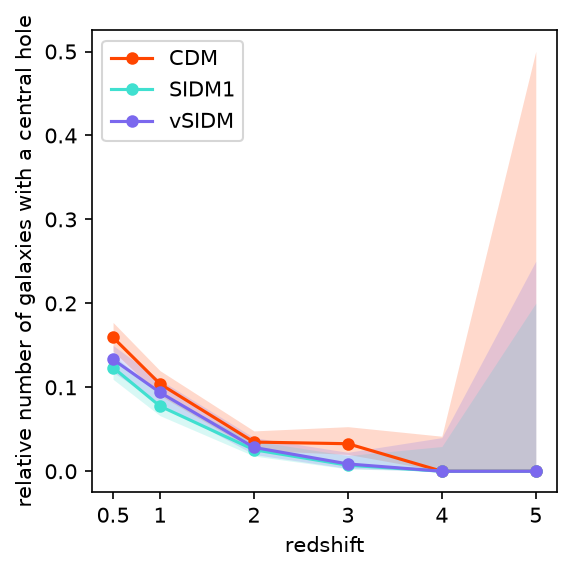

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
shown = set() # redshifts where some model has a value, for the ticks
for model in models:
    n_hole = np.array([sum(start > min_hole for radius, start in first[(model, z)]) for z in redshifts])
    n_all = np.array([len(first[(model, z)]) for z in redshifts])
    rel_count = n_hole / n_all
    lo, hi = binom_conf_interval(n_hole, n_all, confidence_level=confidence, interval="wilson")
    ax.plot(redshifts, rel_count, "o-", markersize=5, label=model, color={"CDM": "orangered", "SIDM1": "turquoise", "vSIDM": "mediumslateblue"}[model])
    ax.fill_between(redshifts, lo, hi, color={"CDM": "orangered", "SIDM1": "turquoise", "vSIDM": "mediumslateblue"}[model], alpha=0.2, lw=0) # range of the median
    shown.update(z for z, v in zip(redshifts, rel_count) if np.isfinite(v) and v != 0)
ax.set_xlabel("redshift")
ax.set_xticks(redshifts, [f"{z:g}" for z in redshifts])
ax.set_ylabel("relative number of galaxies with a central hole")
# ax.set_ylim(0)
ax.legend()
plt.show()

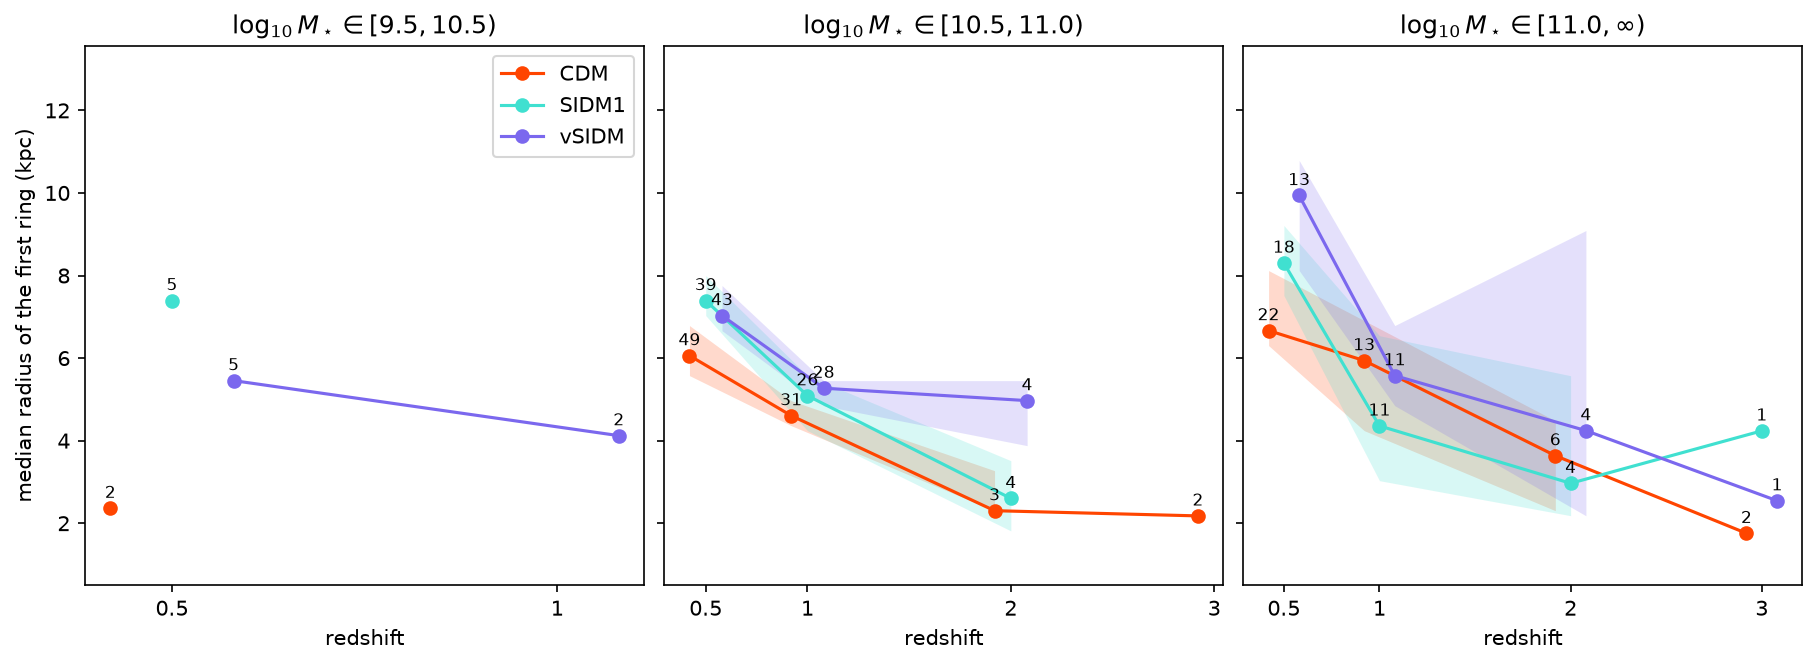

In [18]:
# the median radius of the first ring in bins of stellar mass (the bins of our other mosaics)
mass_edges = [9.5, 10.5, 11.0]
bins = list(zip(mass_edges[:-1], mass_edges[1:])) + [(mass_edges[-1], np.inf)]
colors = {"CDM": "orangered", "SIDM1": "turquoise", "vSIDM": "mediumslateblue"}
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150, sharey=True, constrained_layout=True)
for ax, (m_lo, m_hi) in zip(axes.flat, bins):
    shown = set() # redshifts where some model has a value in this panel, for the ticks
    for model in models:
        medians, lows, highs = [], [], []
        for z in redshifts:
            r = np.array([radius for (radius, start), lm in zip(first[(model, z)], logm[(model, z)])
                          if start > min_hole and m_lo <= lm < m_hi])
            if len(r):
                med = np.median(r)
                ci = quantile_test(r, p=0.5).confidence_interval(confidence_level=confidence)
                lo, hi = ci.low, ci.high
                ax.annotate(f"{len(r):d}", (z + offset[model], med), textcoords="offset points", xytext=(0, 5),
                            ha="center", fontsize=8)
            else:
                med = lo = hi = np.nan
            medians.append(med)
            lows.append(lo)
            highs.append(hi)
        ax.plot(np.array(redshifts) + offset[model], medians, "o-", markersize=6, label=model, color=colors[model])
        ax.fill_between(np.array(redshifts) + offset[model], lows, highs, color=colors[model], alpha=0.2, lw=0)
        shown.update(z for z, v in zip(redshifts, medians) if np.isfinite(v) and v != 0)
    top = f"{m_hi:.1f}" if np.isfinite(m_hi) else r"\infty"
    ax.set_title(rf"$\log_{{10}} M_\star \in [{m_lo:.1f}, {top})$")
    ax.set_xlabel("redshift")
    ax.set_xticks(sorted(shown), [f"{z:g}" for z in sorted(shown)]) # only the redshifts with data
for ax in axes.flat[len(bins):]:
    ax.set_visible(False) # five bins, six panels
for ax in axes[:, 0]:
    ax.set_ylabel("median radius of the first ring (kpc)")
axes[0, 0].legend()
plt.show()